<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/Intro_to_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision

Welcome! In this notebook, we will explore the basics of Computer Vision (CV). Computer Vision is the field of Artificial Intelligence that enables computers to "see" and understand digital images and videos.

Today, we will use **OpenCV** (Open Source Computer Vision Library), one of the most popular tools used by engineers and researchers worldwide.

**What we will cover:**
1. Loading and displaying images
2. Understanding Color Spaces (Grayscale)
3. Extracting Features (Edge Detection)
4. AI in Action (Face Detection)

In [1]:
# First, let's import the necessary libraries
import cv2 # OpenCV
import numpy as np # For numerical operations and matrix math
import matplotlib.pyplot as plt # For displaying our images
import urllib.request # To download sample files

# Download a sample image and a face detection model file
image_url = "https://raw.githubusercontent.com/nielitropar/computer-vision/refs/heads/main/assets/Sarwan_Singh.JPG"
xml_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"

urllib.request.urlretrieve(image_url, "sample.jpg")
urllib.request.urlretrieve(xml_url, "haarcascade_frontalface_default.xml")

print("Setup complete! Libraries imported and files downloaded.")

Setup complete! Libraries imported and files downloaded.


## 1. Loading and Displaying Images
To a computer, an image is just a giant grid of numbers (a matrix). Each number represents the brightness of a specific color at a specific pixel.

Let's load our sample image and take a look.

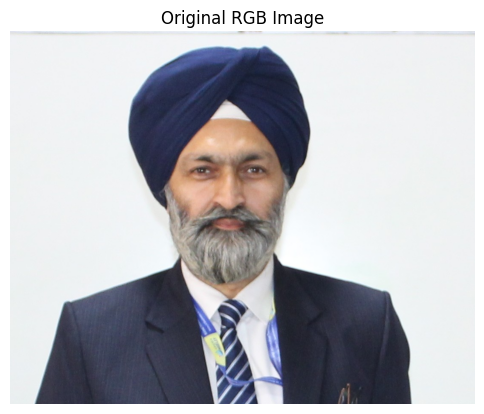

The image shape is: (874, 1091, 3)


In [2]:
# Read the image using OpenCV
# By default, OpenCV reads images in BGR (Blue, Green, Red) format
img_bgr = cv2.imread("sample.jpg")

# Matplotlib expects RGB (Red, Green, Blue) format, so we need to convert it
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off') # Hide the axes for a cleaner look
plt.title("Original RGB Image")
plt.show()

# Let's see the underlying matrix shape: (Height, Width, Color Channels)
print(f"The image shape is: {img_bgr.shape}")

## 2. Color Spaces: Moving to Grayscale
Color is great for human eyes, but it often adds unnecessary complexity for computers trying to understand shapes or structures. Converting an image to grayscale reduces the data by a factor of 3 (from 3 color channels down to 1), making processing much faster.

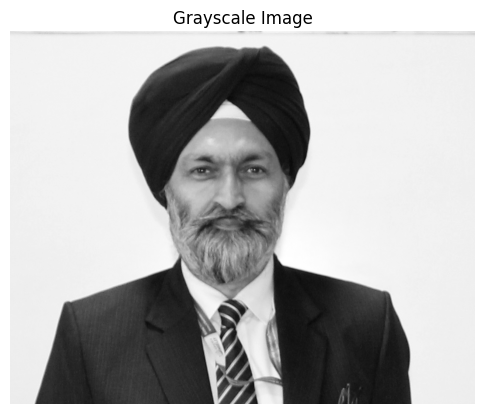

The grayscale image shape is: (874, 1091)


In [3]:
# Convert the original BGR image to Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray') # We must specify the colormap as 'gray'
plt.axis('off')
plt.title("Grayscale Image")
plt.show()

print(f"The grayscale image shape is: {img_gray.shape}")

In [4]:
from google.colab import ai
from IPython.display import Markdown, display
response = ai.generate_text("Color Spaces: Moving to Grayscale Using OpenCV")

# Display as Markdown
display(Markdown(response))

Converting an image to grayscale is one of the most fundamental operations in image processing. It simplifies the image by removing color information, making it easier for many computer vision algorithms to process.

In OpenCV, the most common and recommended way to convert an image to grayscale is by using the `cv2.cvtColor()` function.

---

### What is Grayscale?

A grayscale image is an image in which the value of each pixel is a single sample representing only an amount of light (luminance). This means that grayscale images contain only shades of gray and no color information. Each pixel's value typically ranges from 0 (black) to 255 (white) in an 8-bit image.

Color images (like RGB or BGR) usually have three channels (Red, Green, Blue). A grayscale image has only one channel.

### Why Convert to Grayscale?

1.  **Reduced Data Size:** A grayscale image takes up less memory and disk space (one channel vs. three).
2.  **Simplified Processing:** Many image processing algorithms (e.g., edge detection, thresholding, contour finding, feature extraction) are simpler and more efficient to implement on grayscale images as they don't need to consider color.
3.  **Focus on Structure/Intensity:** Grayscale images highlight the structural information and intensity variations, which are often more relevant for tasks like object recognition or analysis.
4.  **Faster Computation:** Less data means faster processing times.

---

### Using `cv2.cvtColor()` for Grayscale Conversion

The `cv2.cvtColor()` function is a versatile tool for converting images between different color spaces.

**Syntax:**
```python
dst = cv2.cvtColor(src, code)
```

*   `src`: The input image (NumPy array).
*   `code`: The color space conversion code.

**Common Codes for Grayscale Conversion:**

*   `cv2.COLOR_BGR2GRAY`: Converts a BGR image to grayscale. (OpenCV loads images in BGR format by default).
*   `cv2.COLOR_RGB2GRAY`: Converts an RGB image to grayscale. (Useful if you've loaded an image using a different library like `matplotlib.pyplot` which uses RGB).

**Example:**

```python
import cv2
import numpy as np

# 1. Load an image
# Make sure to replace 'path_to_your_image.jpg' with the actual path to your image file
image_path = 'lena.jpg' # Example: make sure you have an image file named 'lena.jpg' in the same directory

image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}")
    exit()

# 2. Convert to Grayscale
# OpenCV loads images in BGR format by default, so we use COLOR_BGR2GRAY
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Display the original and grayscale images
cv2.imshow('Original Image', image)
cv2.imshow('Grayscale Image', gray_image)

# 4. Print image dimensions to see the change in channels
print(f"Original image shape: {image.shape}") # e.g., (height, width, 3)
print(f"Grayscale image shape: {gray_image.shape}") # e.g., (height, width) - note the missing 3rd dimension

# 5. Save the grayscale image (optional)
cv2.imwrite('grayscale_lena.jpg', gray_image)
print("Grayscale image saved as 'grayscale_lena.jpg'")

# 6. Wait for a key press and then close all windows
cv2.waitKey(0)
cv2.destroyAllWindows()
```

**Explanation:**

1.  **`cv2.imread(image_path)`**: Loads the image from the specified path. OpenCV reads images as NumPy arrays, with pixel values in BGR (Blue, Green, Red) order by default.
2.  **`cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)`**: This is the core conversion step. It takes the original BGR image and applies a weighted average formula (see below) to convert each BGR pixel into a single grayscale intensity value.
3.  **`image.shape`**: For a color image, this will typically output `(height, width, 3)`, indicating three color channels.
4.  **`gray_image.shape`**: For a grayscale image, this will typically output `(height, width)`, indicating a single channel (OpenCV often omits the 1 for single-channel images, treating them as 2D arrays).

---

### How Grayscale Conversion Works (The Math)

When you convert a color image to grayscale, it's not simply discarding the color channels. Instead, a weighted sum of the R, G, and B components is calculated to represent the perceived brightness (luminance) of the pixel. This is because humans perceive different colors with varying brightness levels (e.g., green often appears brighter than red or blue).

The most common formula used by OpenCV (and others like ITU-R BT.601 standard for NTSC) for luminance (`Y`) is:

$ Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B $

*   **R, G, B**: The Red, Green, and Blue pixel values (typically 0-255).
*   **Y**: The resulting grayscale (luminance) value for that pixel.

This formula assigns the highest weight to Green (as the human eye is most sensitive to green light), followed by Red, and then Blue.

---

### Alternative (Manual) Ways to Get Grayscale (for understanding, not recommended for production)

While `cv2.cvtColor()` is the most efficient and accurate method, understanding how it *could* be done manually can be insightful.

**1. Extracting a Single Channel:**

You can technically "grayscale" an image by just taking one of its color channels. However, this is not true grayscale as it only shows the intensity of that specific color component, not the overall brightness.

```python
# Using the image loaded from the previous example
blue_channel = image[:, :, 0] # Extract the blue channel
green_channel = image[:, :, 1] # Extract the green channel
red_channel = image[:, :, 2] # Extract the red channel

cv2.imshow('Blue Channel', blue_channel)
cv2.imshow('Green Channel', green_channel)
cv2.imshow('Red Channel', red_channel)
cv2.waitKey(0)
cv2.destroyAllWindows()
```
*Notice how these "grayscale" images look different from the one produced by `cv2.cvtColor()`.*

**2. Simple Averaging:**

You could average the R, G, and B values. This is simpler but doesn't account for human perception as accurately as the weighted average.

```python
# Using the image loaded from the previous example
# Convert to float for calculation, then back to uint8
image_float = image.astype(np.float32)
average_gray = (image_float[:,:,0] + image_float[:,:,1] + image_float[:,:,2]) / 3
average_gray = average_gray.astype(np.uint8)

cv2.imshow('Average Grayscale', average_gray)
cv2.waitKey(0)
cv2.destroyAllWindows()
```

**3. Manual Weighted Averaging (Mimicking `cvtColor`):**

This explicitly applies the luminance formula. Remember OpenCV images are BGR, so `image[:, :, 0]` is Blue, `image[:, :, 1]` is Green, and `image[:, :, 2]` is Red.

```python
# Using the image loaded from the previous example
# Convert to float for calculation, then back to uint8
image_float = image.astype(np.float32)

# Applying the luminance formula (0.299*R + 0.587*G + 0.114*B)
# R is image_float[:,:,2], G is image_float[:,:,1], B is image_float[:,:,0]
weighted_gray = (0.299 * image_float[:,:,2] +
                 0.587 * image_float[:,:,1] +
                 0.114 * image_float[:,:,0])
weighted_gray = weighted_gray.astype(np.uint8)

cv2.imshow('Manual Weighted Grayscale', weighted_gray)
cv2.waitKey(0)
cv2.destroyAllWindows()
```
*You'll notice this manual `weighted_gray` image looks very similar, if not identical, to the `gray_image` produced by `cv2.cvtColor()` because it uses the same underlying principle.*

---

### Conclusion

For converting images to grayscale in OpenCV, `cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)` is the **standard, most efficient, and perceptually accurate** method. It's the go-to function for almost all practical applications involving grayscale conversion.

## 3. Extracting Features: Edge Detection
How do we find objects in an image? We look for boundaries. Edges occur where there is a sharp change in pixel brightness (e.g., a dark object against a light background).

We will use the **Canny Edge Detector**, a classic and highly effective algorithm.

In [5]:
from google.colab import ai
from IPython.display import Markdown, display
response = ai.generate_text("Canny Edge Detector")

# Display as Markdown
display(Markdown(response))

The **Canny Edge Detector** is a widely used and highly effective edge detection operator in computer vision. Developed by John F. Canny in 1986, its primary goal is to identify points in a digital image where the image brightness changes sharply, i.e., to find "edges."

Canny's design had three main criteria:
1.  **Good Detection:** The algorithm should mark as many true edges as possible.
2.  **Good Localization:** The detected edges should be as close as possible to the true edges.
3.  **Minimal Response:** A given edge in the image should only be marked once, and there should be no spurious edge points.

It's a multi-stage algorithm that typically involves five distinct steps:

### The Five Steps of Canny Edge Detection:

#### 1. Noise Reduction (Gaussian Smoothing)
*   **Purpose:** Raw image data often contains noise, which can lead to spurious edges. Before computing gradients, it's crucial to smooth the image to reduce noise.
*   **How it works:** The image is convolved with a Gaussian filter (a 2D Gaussian kernel). This blurs the image slightly, effectively averaging pixel values and suppressing noise while preserving edges.
*   **Parameter:** The standard deviation (`sigma`) of the Gaussian kernel determines the level of smoothing. A larger `sigma` results in more blurring.

#### 2. Gradient Calculation
*   **Purpose:** To detect the intensity gradients (magnitude and direction) in the smoothed image. Edges are regions of high intensity gradient.
*   **How it works:**
    *   The smoothed image is filtered with a Sobel operator (or Prewitt, Scharr) in both horizontal ($G_x$) and vertical ($G_y$) directions to get the first derivatives.
    *   The **edge magnitude** (strength) is then calculated using the hypotenuse:
        $G = \sqrt{G_x^2 + G_y^2}$
        (or sometimes approximated as $G = |G_x| + |G_y|$ for computational efficiency).
    *   The **edge direction** (orientation) is calculated using the arctangent of the derivatives:
        $\theta = \operatorname{atan2}(G_y, G_x)$
    *   The angle $\theta$ is usually rounded to one of four common directions: 0°, 45°, 90°, or 135°, corresponding to horizontal, diagonal, and vertical edges.

#### 3. Non-Maximum Suppression (NMS)
*   **Purpose:** To thin the edges, ensuring that there is only one response for each edge. Gradient magnitudes often produce thick edges.
*   **How it works:** For every pixel, the algorithm checks if its gradient magnitude is the maximum along the gradient direction.
    *   It compares the pixel's magnitude with the magnitudes of its two neighbors along the *calculated gradient direction*.
    *   If the current pixel's magnitude is not greater than both of its neighbors along that direction, it is suppressed (set to zero). Otherwise, it is kept.
    *   This step helps to get rid of pixels that are not truly at the peak of an edge.

#### 4. Double Thresholding (Hysteresis Thresholding)
*   **Purpose:** To differentiate between strong, weak, and non-edges, and to connect weak edges that are part of a strong edge.
*   **How it works:** Two thresholds, `T_high` (high threshold) and `T_low` (low threshold), are used:
    *   **Strong edges:** Pixels with a gradient magnitude *greater than `T_high`* are considered strong edge pixels and are immediately included in the final edge map.
    *   **Weak edges:** Pixels with a gradient magnitude *between `T_low` and `T_high`* are considered weak edge pixels. These are kept as potential edges.
    *   **Non-edges:** Pixels with a gradient magnitude *less than `T_low`* are suppressed (discarded).
*   **Benefit:** `T_high` helps to identify definite edges, while `T_low` helps to pick up valid weak edges that are connected to strong ones.

#### 5. Edge Tracking by Hysteresis
*   **Purpose:** To finalize the edge map by converting weak edges into strong edges if they are connected to strong edges, and discarding isolated weak edges.
*   **How it works:** The algorithm starts from the strong edge pixels and recursively or iteratively tracks paths of weak edge pixels that are connected to them.
    *   Any weak pixel that is connected to a strong pixel (or another weak pixel that has already been confirmed as part of a strong edge) is classified as a strong edge.
    *   Weak pixels that are not connected to any strong edge pixels are discarded.
*   **Benefit:** This step helps to connect broken edge segments and eliminate spurious edges caused by noise, leading to more continuous and robust edge maps.

### Advantages of Canny Edge Detector:
*   **Optimal Performance:** Designed to satisfy all three Canny criteria (good detection, good localization, minimal response).
*   **Robust to Noise:** Gaussian smoothing effectively reduces noise impact.
*   **Thin Edges:** Non-maximum suppression ensures single-pixel wide edges.
*   **Connects Edges:** Hysteresis thresholding helps connect broken edge segments, producing continuous edges.
*   **Parameter Control:** Offers control over sensitivity through `sigma` and the two thresholds.

### Disadvantages:
*   **Computationally Intensive:** More complex and slower than simpler methods like Sobel or Prewitt due to its multi-stage nature.
*   **Parameter Tuning:** Optimal performance often requires careful tuning of the `sigma`, `T_high`, and `T_low` parameters, which can be application-dependent.
*   **Can Miss Faint Edges:** If `T_low` is set too high, some genuinely weak but important edges might be missed.

### Applications:
Canny edge detection is widely used in various computer vision tasks, including:
*   Object recognition and detection
*   Feature extraction
*   Image segmentation
*   Medical image analysis
*   Robotics (e.g., obstacle detection, navigation)

### Example in Python using OpenCV:

```python
import cv2
import matplotlib.pyplot as plt

# Load an image
image_path = 'image.jpg' # Replace with your image path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # Load as grayscale

if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Apply Canny edge detector
    # Parameters: image, threshold1, threshold2
    # threshold1 (T_low), threshold2 (T_high)
    # Recommended ratio for T_high:T_low is 2:1 or 3:1
    edges = cv2.Canny(img, threshold1=100, threshold2=200)

    # Display the original and edge-detected images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')

    plt.show()

    # You can also save the output
    # cv2.imwrite('canny_edges.jpg', edges)
```

In OpenCV's `cv2.Canny()` function, the `threshold1` and `threshold2` arguments correspond to `T_low` and `T_high` respectively. There are also optional arguments like `apertureSize` (for the Sobel operator, defaults to 3) and `L2gradient` (to use the exact magnitude calculation `sqrt(Gx^2 + Gy^2)` instead of the approximation `|Gx| + |Gy|`).

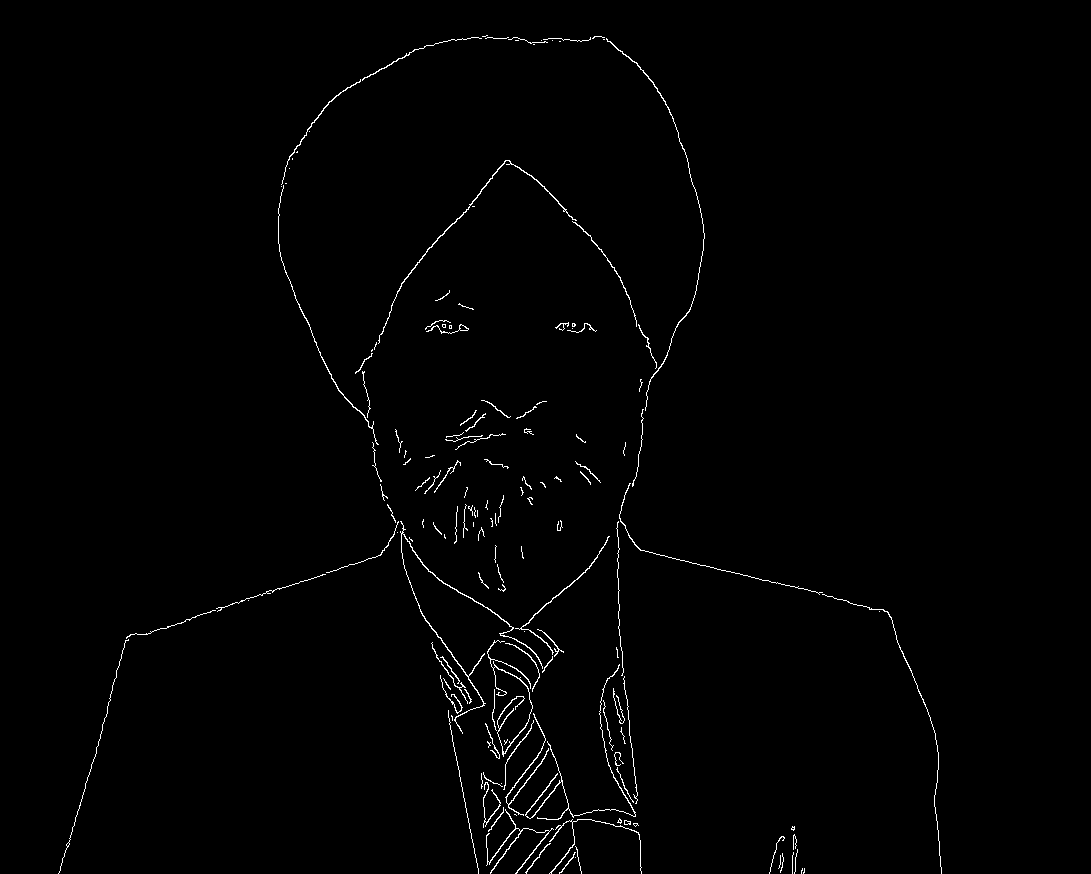

In [6]:
# Apply Canny Edge Detection
# The numbers 100 and 200 are the lower and upper thresholds for detecting strong vs. weak edges.
from google.colab.patches import cv2_imshow

edges = cv2.Canny(img_gray, 100, 200)

cv2_imshow(edges)

# plt.figure(figsize=(6, 6))
# plt.imshow(edges, cmap='gray')
# plt.axis('off')
# plt.title("Canny Edge Detection")
# plt.show()

## 4. AI in Action: Face Detection
Now let's do something advanced: detecting a human face.

Before modern Deep Learning, engineers used algorithms like **Haar Cascades**. These are pre-trained machine learning models that scan the image looking for specific patterns of light and dark that typically make up a human face (like the eyes being darker than the forehead).

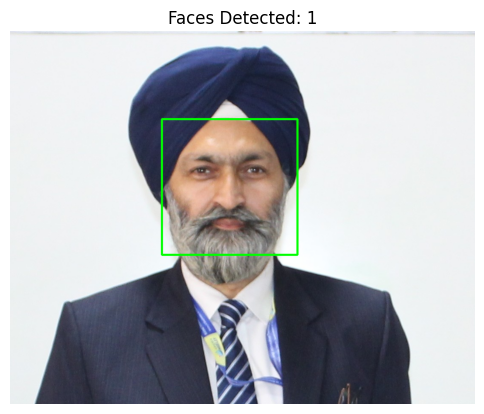

In [7]:
# Load the pre-trained Haar Cascade model for frontal faces
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Detect faces in the grayscale image
# scaleFactor compensates for faces being closer/further from the camera
# minNeighbors defines how many objects are detected near the current one before it declares the face found
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5)

# Make a copy of the original RGB image to draw on
img_faces = img_rgb.copy()

# Loop over all detected faces and draw a rectangle around them
for (x, y, w, h) in faces:
    # cv2.rectangle(image, start_point, end_point, color, thickness)
    cv2.rectangle(img_faces, (x, y), (x+w, y+h), (0, 255, 0), 4)

plt.figure(figsize=(6, 6))
plt.imshow(img_faces)
plt.axis('off')
plt.title(f"Faces Detected: {len(faces)}")
plt.show()

## **Congratulations!**
You've just completed your first Computer Vision pipeline. You learned how to:
* Translate images into mathematical matrices.
* Manipulate color spaces for efficiency.
* Extract structural features (edges).
* Apply a machine learning model to detect complex objects (faces).

**Next Steps:** Try uploading your own image to Colab and changing the `image_url` to point to your file to see how the algorithms perform on different data!



---



In [8]:
from google.colab import ai
from IPython.display import Markdown, display
response = ai.generate_text("What is YoLo?")

# Display as Markdown
display(Markdown(response))

**YOLO stands for "You Only Look Once."**

It is a state-of-the-art, real-time object detection system in the field of computer vision. Its primary goal is to identify and locate various objects within an image or video frame by drawing bounding boxes around them and assigning a class label (e.g., "person," "car," "dog").

### How YOLO Works (Simplified)

Unlike older object detection systems that perform object localization and classification in separate stages (e.g., region proposal followed by classification), YOLO does it all in a **single pass** of a neural network. This "you only look once" approach is what makes it incredibly fast.

Here's a simplified breakdown:

1.  **Divide Image into Grid:** The input image is divided into an S x S grid (e.g., 7x7).
2.  **Predictions per Grid Cell:** Each grid cell is responsible for:
    *   **Predicting Bounding Boxes:** If the center of an object falls into a particular grid cell, that cell predicts a set of bounding boxes (typically 2 or more per cell). A bounding box includes:
        *   `x, y` coordinates (center of the box)
        *   `width, height` (dimensions of the box)
    *   **Confidence Score:** For each predicted bounding box, the cell also predicts a confidence score, which indicates how likely it is that the box contains an object (regardless of its class) and how accurate the predicted box is.
    *   **Class Probabilities:** Each cell also predicts class probabilities (e.g., 90% "dog", 5% "cat", 2% "car"), which specify the likelihood of the object belonging to each predefined class.
3.  **Simultaneous Prediction:** All these predictions (bounding box coordinates, confidence scores, and class probabilities) are made simultaneously by the neural network in one forward pass.
4.  **Non-Maximum Suppression (NMS):** After the network makes all its predictions, there might be multiple overlapping bounding boxes for the same object. A technique called Non-Maximum Suppression (NMS) is applied to filter out redundant boxes, leaving only the most confident and accurate ones.

### Key Features and Advantages

*   **Speed:** YOLO is exceptionally fast, capable of real-time processing (often 30-60+ frames per second) on standard GPUs. This makes it suitable for applications like self-driving cars, robotics, and live video analysis.
*   **End-to-End Learning:** It's a single, unified neural network that directly predicts bounding boxes and class probabilities. This simplifies the pipeline and allows the network to optimize all aspects directly.
*   **Contextual Understanding:** Because it "sees" the entire image during training and inference, YOLO implicitly encodes contextual information about classes and their appearance. This helps it reduce background errors (false positives) compared to region proposal-based methods.
*   **Generalized Representations:** YOLO learns more generalized features, making it robust when applied to new domains or unexpected inputs.
*   **High Accuracy (for its speed):** While initially slightly less accurate than some two-stage detectors, subsequent versions of YOLO have significantly closed this gap, offering excellent accuracy at unmatched speeds.

### Disadvantages/Limitations

*   **Detecting Small Objects:** YOLO can struggle with very small objects, especially if they appear in groups (e.g., a flock of birds). Each grid cell predicts a limited number of bounding boxes, so if multiple small objects fall within one cell, it might miss some.
*   **Suboptimal Bounding Box Precision:** Compared to some more complex, two-stage detectors, earlier versions of YOLO sometimes produced less precise bounding box localizations. However, newer versions have greatly improved this.
*   **Objects in Close Proximity:** If multiple objects are centered in the same grid cell, YOLO can only detect one, as each cell is designed to predict only a few objects.

### Evolution of YOLO

Since its initial release (YOLOv1) by Joseph Redmon et al. in 2016, YOLO has undergone numerous iterations, each introducing architectural improvements, new training techniques, and optimizations. Notable versions include:

*   **YOLOv1, YOLOv2 (YOLO9000), YOLOv3:** Original series by Redmon et al.
*   **YOLOv4:** Developed by Alexey Bochkovskiy et al., pushing accuracy and speed further.
*   **YOLOv5:** Developed by Ultralytics, known for its ease of use and PyTorch integration.
*   **YOLOv6, YOLOv7, YOLOv8, YOLOv9:** More recent versions from various research groups, continuing to advance the state-of-the-art in object detection.

### Applications

YOLO's speed and accuracy make it incredibly versatile, used in a wide range of applications:

*   **Self-driving cars:** Detecting pedestrians, other vehicles, traffic signs, and lanes in real-time.
*   **Robotics:** Enabling robots to perceive and interact with their environment.
*   **Surveillance and Security:** Identifying suspicious activities, tracking individuals, or detecting unauthorized objects.
*   **Retail Analytics:** Monitoring customer behavior, managing inventory, and optimizing store layouts.
*   **Sports Analysis:** Tracking players, balls, and events in real-time.
*   **Medical Imaging:** Assisting in the detection of anomalies or features in medical scans.
*   **Augmented Reality (AR):** Real-time object recognition for interactive AR experiences.

In essence, YOLO revolutionized object detection by prioritizing speed without sacrificing too much accuracy, opening up new possibilities for real-time computer vision applications. It remains one of the most popular and influential architectures in the field.

Before Joseph Redmon’s original paper in 2015, object detection was a multi-stage "Frankenstein" process (like R-CNN). You’d propose regions, then classify them—it was slow and clunky. YOLO turned it into a single regression problem: one pass through the network, and you get both bounding boxes and class probabilities.

In [9]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

# Load the latest model (YOLO11 Nano is an excellent, lightweight starting point)
# Note: You can scale up to 'yolo11s.pt' (small), 'yolo11m.pt' (medium), or 'yolo11x.pt' (extra-large) based on your accuracy needs.
model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
# Run prediction on a sample image (setting a 50% confidence threshold)
results = model.predict(source="https://wellsr.com/python/assets/images/2022-02-04-test_image.jpg", save=True, conf=0.5)

# (Optional) Print out the detected classes and coordinates
for result in results:
    boxes = result.boxes  # Bounding box outputs
    print("Detected Classes:", boxes.cls)
    print("Confidence Scores:", boxes.conf)


image 1/1 /content/2022-02-04-test_image.jpg: 416x640 2 persons, 1 bicycle, 1 car, 48.5ms
Speed: 4.6ms preprocess, 48.5ms inference, 42.2ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict
Detected Classes: tensor([0., 1., 0., 2.], device='cuda:0')
Confidence Scores: tensor([0.8997, 0.8960, 0.8942, 0.8490], device='cuda:0')


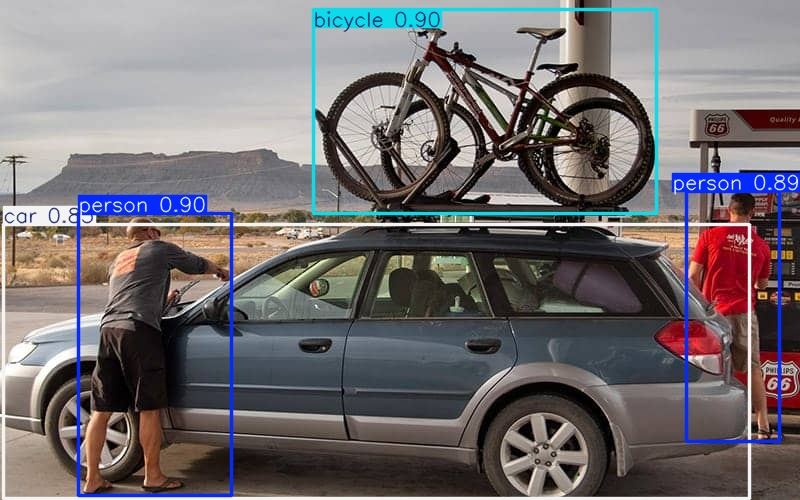

In [14]:
from IPython.display import display, Image

# Display the annotated image
display(Image(filename='/content/runs/detect/predict/2022-02-04-test_image.jpg'))

In [15]:
# Process the video
# video_results = model.predict(source="test.mp4", save=True)